# EU Weekly Oil Bulletin — Fuel Price Analysis (2005–2026)

**Dataset:** Weekly pump prices for petrol, diesel, heating oil and LPG across all 27 EU member states + UK since January 2005 — 106,000+ data points, cleaned from the European Commission Weekly Oil Bulletin into one flat CSV.

**Author:** Fionn Hughes

---

## What this notebook covers

1. **Data Overview** — shape, countries, fuel types, date range
2. **Ireland: 21 Years of Petrol & Diesel** — full price history with crisis annotations
3. **Crisis Comparison** — how the 2026 Iran war compares to 2008, COVID and Ukraine war, indexed to 100
4. **Rate of Rise** — quantifying how fast prices are climbing during each crisis (slope analysis)
5. **EU Country Rankings** — who pays most and least at the pump right now
6. **EU Price Map** — choropleth map of current petrol and diesel prices across Europe
7. **Diesel vs Petrol Gap** — how the spread between fuel types has changed over time
8. **2026 vs Previous Years** — zoomed in on Jan–Apr, showing the Iran war spike against 2024 and 2025
9. **Annual Heatmap** — every country × every year, coloured by average price
10. **Affordability** — hours of minimum wage work to fill a 50L tank in Ireland, 2005–2026
11. **Key Findings** — summary stats, the numbers worth sharing

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
import seaborn as sns
import pandas as pd
import numpy as np

DATA_PATH = '/kaggle/input/datasets/fionnhughes/eu-oil-bulletin/eu_oil_bulletin.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['date'])

print(df.head())

        date country    fuel_type  price_eur_per_litre
0 2005-01-03      AT       diesel              0.85900
1 2005-01-03      AT     fuel_oil              0.21670
2 2005-01-03      AT  heating_oil              0.49522
3 2005-01-03      AT    petrol_95              0.91600
4 2005-01-03      BE       diesel              0.89100


In [2]:
# strip whitespaces
df['country'] = df['country'].str.strip()
df['fuel_type'] = df['fuel_type'].str.strip()

# dropping EU/EUR aggregate rows for country-level analysis
df_countries = df[~df['country'].isin(['EU','EUR'])]
df_eu = df[df['country'] == 'EU'].copy()

print(sorted(df_countries['country'].unique()))
print(sorted(df['fuel_type'].unique()))

['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'UK']
['diesel', 'fuel_oil', 'heating_oil', 'lpg', 'petrol_95']


In [3]:
# adding the signature style

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.grid': True,
    'grid.color': '#2a2a2a',
    'xtick.color': '#888888',
    'ytick.color': '#888888',
    'axes.labelcolor': '#cccccc',
    'axes.titlecolor': '#ffffff',
    'font.family': 'monospace',
    'axes.titlesize': 14,
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#333333',
})

# setting colours for different lines
IRELAND_GREEN  = '#169b62'
PETROL_BLUE    = '#4a9eff'
DIESEL_ORANGE  = '#f5a623'
CRISIS_RED     = '#ff4444'
HEATING_PURPLE = '#b066ff'

# naming the main crises which affected oil prices
CRISES = [
    ('2008-07-01', '2008\nCrisis'),
    ('2020-03-01', 'COVID'),
    ('2022-02-24', 'Ukraine\nWar'),
    ('2026-02-28', 'Iran\nWar'),
]

crisis_colors = ['#aaaaaa', '#44bbff', '#ffdd00', CRISIS_RED]

def add_crisis_lines(ax, ypos=0.97):
    for date_str, label in CRISES:
        x = pd.Timestamp(date_str)
        y = ax.get_ylim()[1] * ypos
        ax.axvline(x, color=CRISIS_RED, linewidth=0.8, linestyle='--', alpha=0.6)
        ax.text(x, y, label, color=CRISIS_RED, fontsize=7, ha='center')
print('style loaded')

style loaded


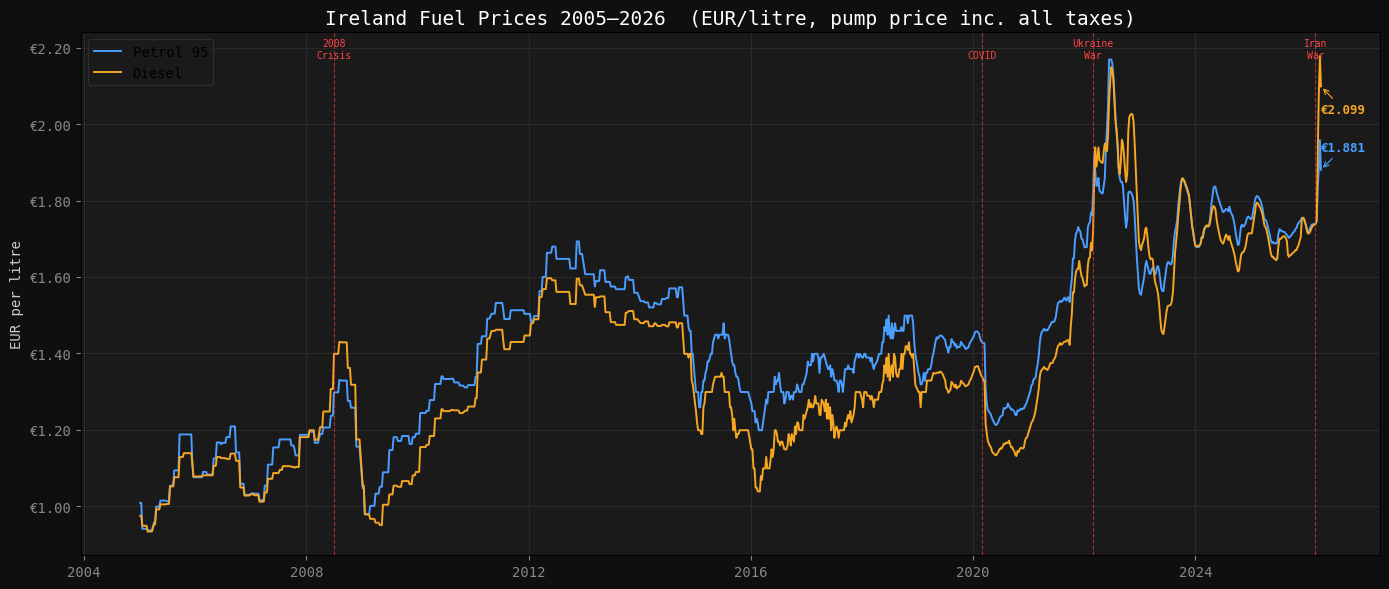

Ireland diesel Jan 2005:  €0.975
Ireland diesel Apr 2026:  €2.099
Ireland diesel percentage change since Jan 2005:  %115.251
Ireland diesel peak price ever on 2026-03-30:  €2.178

Ireland petrol Jan 2005:  €1.009
Ireland petrol Apr 2026:  €1.881
Ireland petrol percentage change since Jan 2005:  %86.373
Ireland petrol peak price ever on 2022-06-13:  €2.169



In [4]:
# Ireland petrol and diesel over 21 years

ie = df_countries[df_countries['country'] == 'IE'].copy()

ie_petrol = ie[ie['fuel_type'] == 'petrol_95'].set_index('date')['price_eur_per_litre']
ie_diesel = ie[ie['fuel_type'] == 'diesel'].set_index('date')['price_eur_per_litre']

# creating plot 
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ie_petrol.index, ie_petrol.values, color=PETROL_BLUE, linewidth=1.4, label='Petrol 95')
ax.plot(ie_diesel.index, ie_diesel.values, color=DIESEL_ORANGE, linewidth=1.4, label = 'Diesel')

#setting title
ax.set_title('Ireland Fuel Prices 2005–2026  (EUR/litre, pump price inc. all taxes)')
ax.set_ylabel('EUR per litre')
ax.legend()

#adding lines for big crises
add_crisis_lines(ax)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('€%.2f'))

#adding the arrows pointing to latest prices
ax.annotate(f'€{ie_petrol.iloc[-1]:.3f}',
            xy = (ie_petrol.index[-1], ie_petrol.iloc[-1]),
            xytext = (ie_petrol.index[-1], ie_petrol.iloc[-1] + 0.05),
            color = PETROL_BLUE,
            fontsize = 9,
            fontweight = 'bold',
            arrowprops = dict(arrowstyle='->', color=PETROL_BLUE, lw=0.8))

ax.annotate(f'€{ie_diesel.iloc[-1]:.3f}',
            xy = (ie_diesel.index[-1], ie_diesel.iloc[-1]),
            xytext = (ie_diesel.index[-1], ie_diesel.iloc[-1] - 0.07),
            color = DIESEL_ORANGE,
            fontsize = 9,
            fontweight = 'bold',
            arrowprops = dict(arrowstyle='->', color=DIESEL_ORANGE, lw=0.8))

fig.tight_layout()
plt.show()

# raw stats
print(f"Ireland diesel Jan 2005:  €{ie_diesel.iloc[0]:.3f}")
print(f"Ireland diesel Apr 2026:  €{ie_diesel.iloc[-1]:.3f}")
print(f"Ireland diesel percentage change since Jan 2005:  %{((ie_diesel.iloc[-1] / ie_diesel.iloc[0]) - 1) * 100:.3f}")
print(f"Ireland diesel peak price ever on {ie_diesel.idxmax().date()}:  €{ie_diesel.max():.3f}\n")

print(f"Ireland petrol Jan 2005:  €{ie_petrol.iloc[0]:.3f}")
print(f"Ireland petrol Apr 2026:  €{ie_petrol.iloc[-1]:.3f}")
print(f"Ireland petrol percentage change since Jan 2005:  %{((ie_petrol.iloc[-1] / ie_petrol.iloc[0]) - 1) * 100:.3f}")
print(f"Ireland petrol peak price ever on {ie_petrol.idxmax().date()}:  €{ie_petrol.max():.3f}\n")


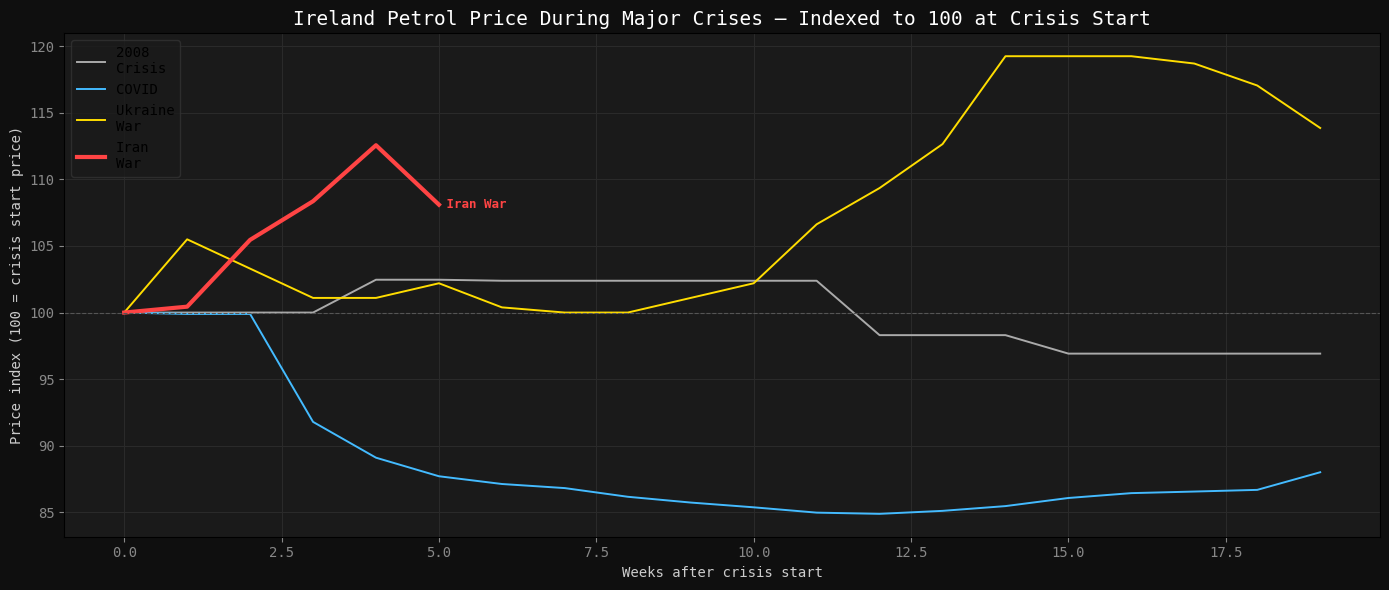

Petrol:
2008 Crisis: -0.26 index points per week
COVID: -0.60 index points per week
Ukraine War: 1.08 index points per week
Iran War: 2.28 index points per week


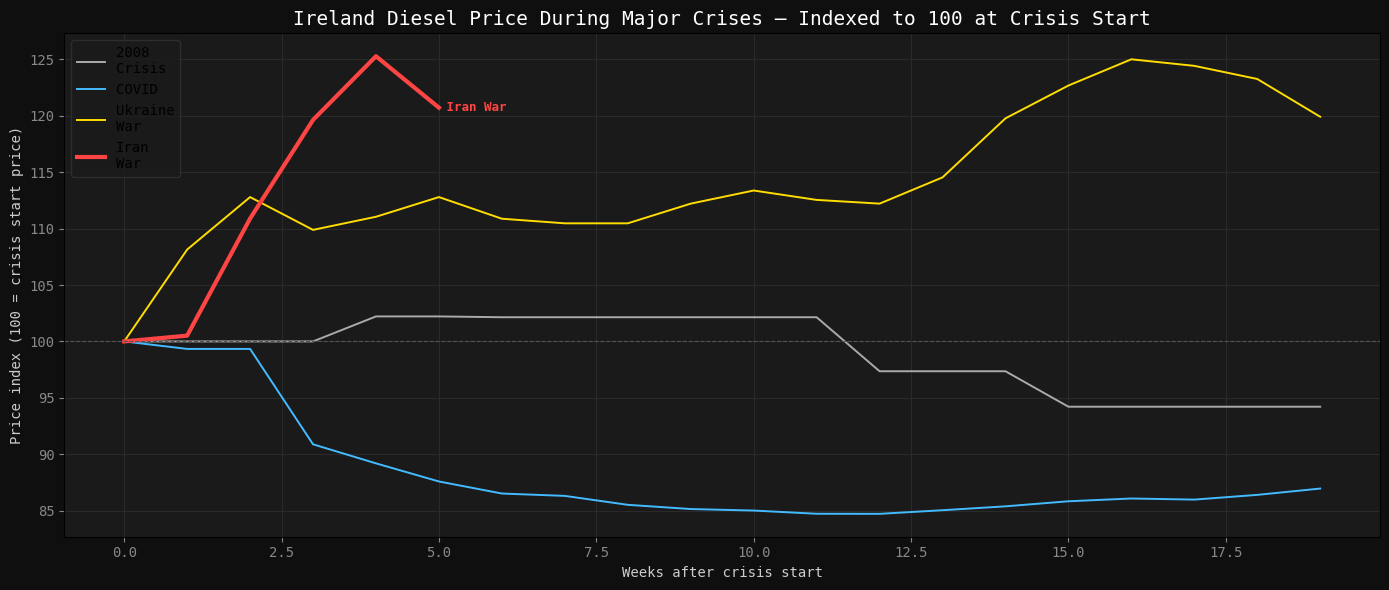

Diesel:
2008 Crisis: -0.42 index points per week
COVID: -0.61 index points per week
Ukraine War: 0.93 index points per week
Iran War: 5.33 index points per week

Diesel is rising 2.3x faster than petrol during the Iran war


In [5]:
# crisis comparison chart - how bad is the 2026 Iran war vs previous shocks.
fig, ax = plt.subplots(figsize=(14, 6))
petrol_slope = []

for (date_str, label), color in zip(CRISES, crisis_colors):
    window = ie_petrol[ie_petrol.index >= date_str].iloc[:20]
    indexed = (window / window.iloc[0]) * 100
    if label == 'Iran\nWar':
        lw = 3
        ax.text(len(indexed)-1, indexed.values[-1], ' Iran War', color=CRISIS_RED, fontsize=9, fontweight='bold', va='center')
    else:
        lw = 1.4
    ax.plot(range(len(indexed)), indexed.values, color=color, linewidth=lw, label=label)
    petrol_slope.append((label, np.polyfit(range(len(indexed)), indexed.values, 1)[0]))
    
#setting title
ax.set_title('Ireland Petrol Price During Major Crises — Indexed to 100 at Crisis Start')
ax.set_ylabel('Price index (100 = crisis start price)')
ax.set_xlabel('Weeks after crisis start')
ax.legend()

ax.axhline(100, color='#555555', linewidth=0.8, linestyle='--')
fig.tight_layout()
plt.show()

print('Petrol:')
for label, slope in petrol_slope:
    print(f"{label.replace('\n',' ')}: \033[1m{slope:.2f}\033[0m index points per week")
    
#diesel version
fig, ax = plt.subplots(figsize=(14, 6))
diesel_slope = []
for (date_str, label), color in zip(CRISES, crisis_colors):
    window = ie_diesel[ie_diesel.index >= date_str].iloc[:20]
    indexed = (window / window.iloc[0]) * 100
    if label == 'Iran\nWar':
        lw = 3
        ax.text(len(indexed)-1, indexed.values[-1], ' Iran War', color=CRISIS_RED, fontsize=9, fontweight='bold', va='center')
    else:
        lw = 1.4
    ax.plot(range(len(indexed)), indexed.values, color=color, linewidth=lw, label=label)
    diesel_slope.append((label, np.polyfit(range(len(indexed)), indexed.values, 1)[0]))
    
    

#setting title
ax.set_title('Ireland Diesel Price During Major Crises — Indexed to 100 at Crisis Start')
ax.set_ylabel('Price index (100 = crisis start price)')
ax.set_xlabel('Weeks after crisis start')
ax.legend()

ax.axhline(100, color='#555555', linewidth=0.8, linestyle='--')
fig.tight_layout()
plt.show()

print('Diesel:')
for label, slope in diesel_slope:
    print(f"{label.replace('\n',' ')}: \033[1m{slope:.2f}\033[0m index points per week")

iran_petrol = petrol_slope[-1][1]
iran_diesel = diesel_slope[-1][1]
print(f"\nDiesel is rising \033[1m{iran_diesel/iran_petrol:.1f}x\033[0m faster than petrol during the Iran war")

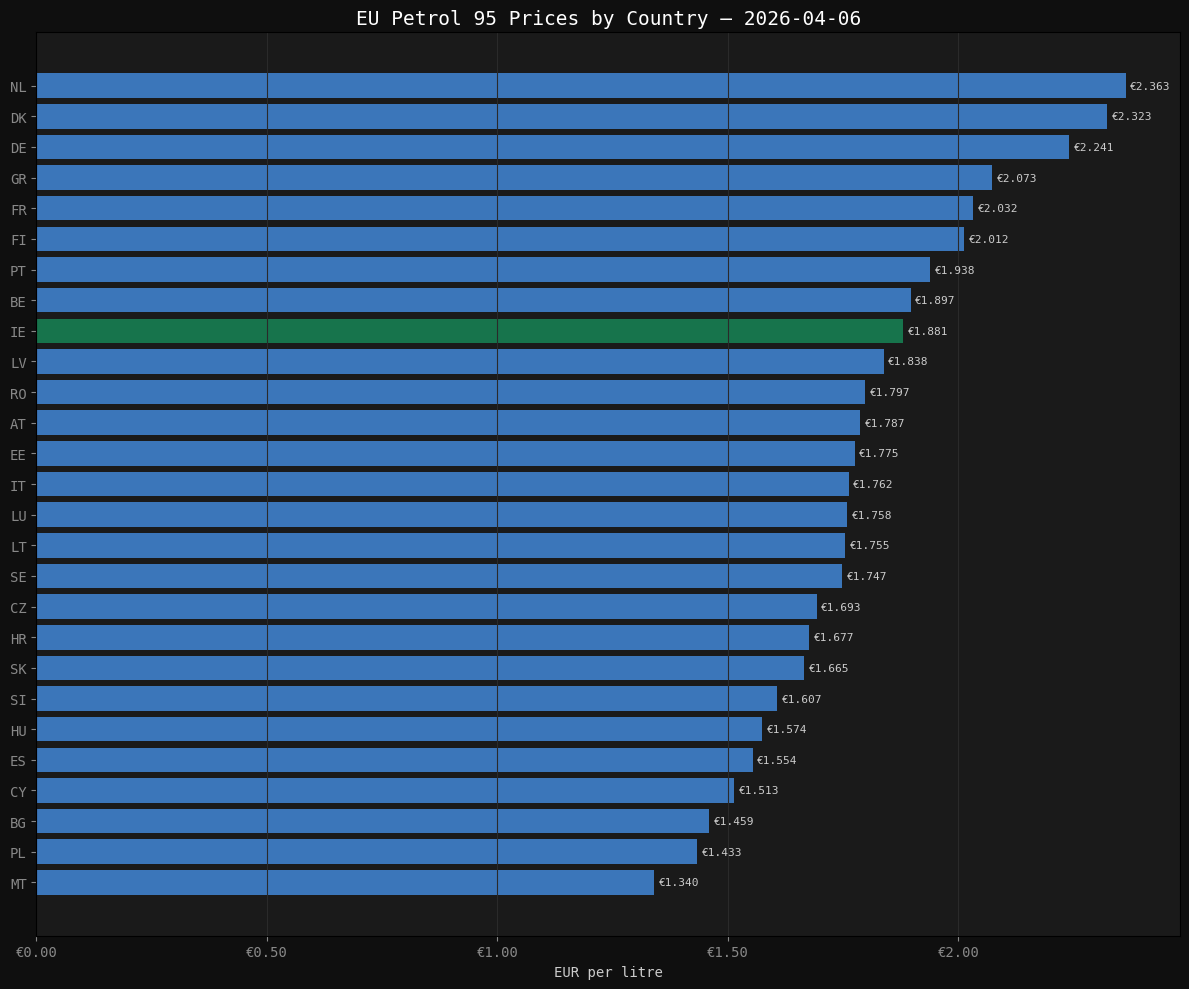

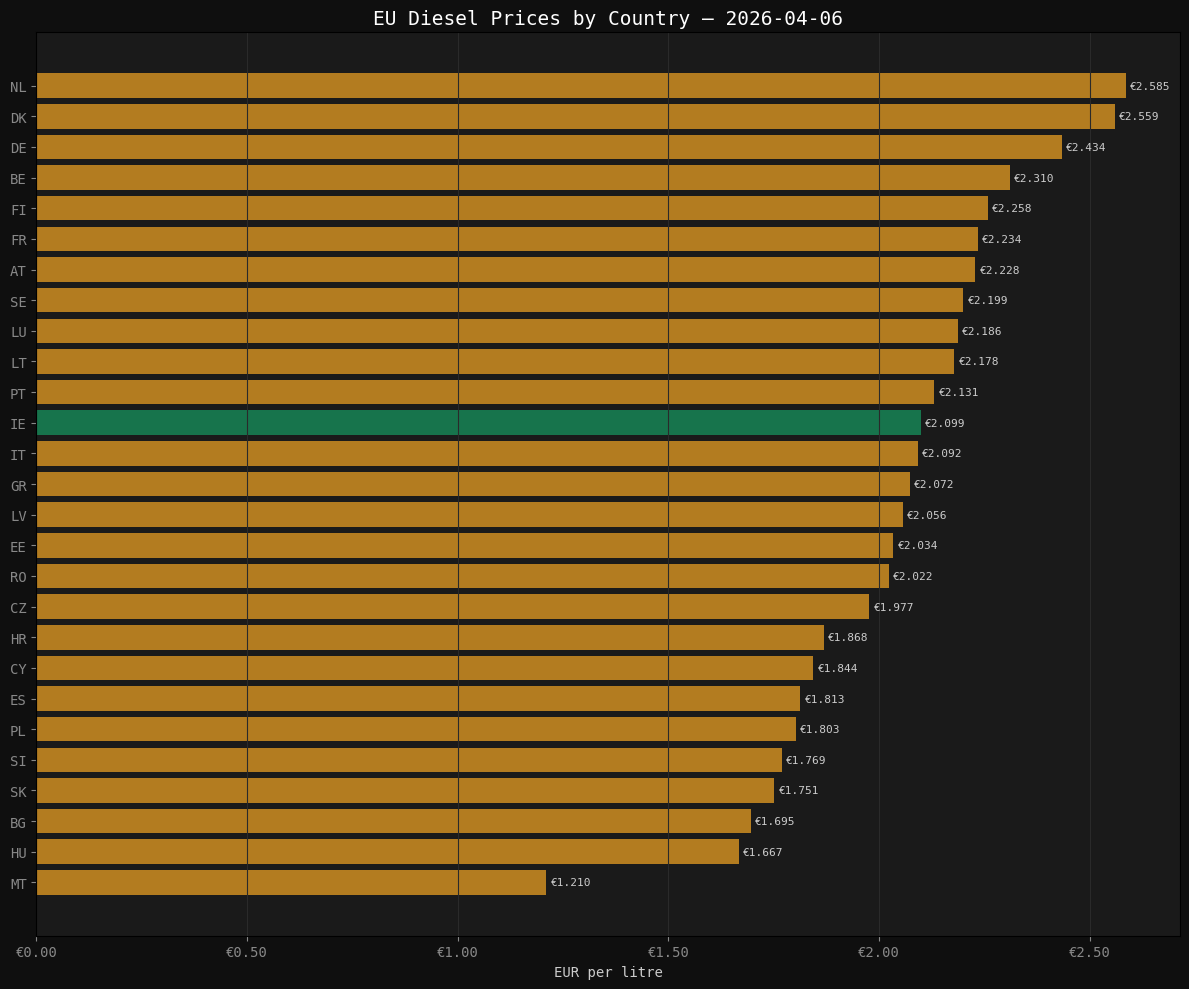

In [6]:
#petrol representation countries
latest_petrol = df_countries[
    (df_countries['date'] == df_countries['date'].max()) &
    (df_countries['fuel_type'] == 'petrol_95')
].copy()

latest_petrol = latest_petrol.sort_values('price_eur_per_litre')
colors = [IRELAND_GREEN if c == 'IE' else PETROL_BLUE for c in latest_petrol['country']]

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(latest_petrol['country'], latest_petrol['price_eur_per_litre'], color=colors, alpha=0.7)

for bar, val in zip(bars, latest_petrol['price_eur_per_litre']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'€{val:.3f}', va='center', fontsize=8, color='#cccccc')

latest_date = df_countries['date'].max().date()
ax.set_title(f'EU Petrol 95 Prices by Country — {latest_date}')
ax.yaxis.grid(False)
ax.set_xlabel('EUR per litre')

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.2f'))
fig.tight_layout()
plt.show()

# diesel representation countries
latest_diesel = df_countries[
    (df_countries['date'] == df_countries['date'].max()) &
    (df_countries['fuel_type'] == 'diesel')
].copy()

latest_diesel = latest_diesel.sort_values('price_eur_per_litre')
colors = [IRELAND_GREEN if c == 'IE' else DIESEL_ORANGE for c in latest_diesel['country']]

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(latest_diesel['country'], latest_diesel['price_eur_per_litre'], color=colors, alpha=0.7)

for bar, val in zip(bars, latest_diesel['price_eur_per_litre']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'€{val:.3f}', va='center', fontsize=8, color='#cccccc')

latest_date = df_countries['date'].max().date()
ax.set_title(f'EU Diesel Prices by Country — {latest_date}')
ax.yaxis.grid(False)
ax.set_xlabel('EUR per litre')

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('€%.2f'))
fig.tight_layout()
plt.show()


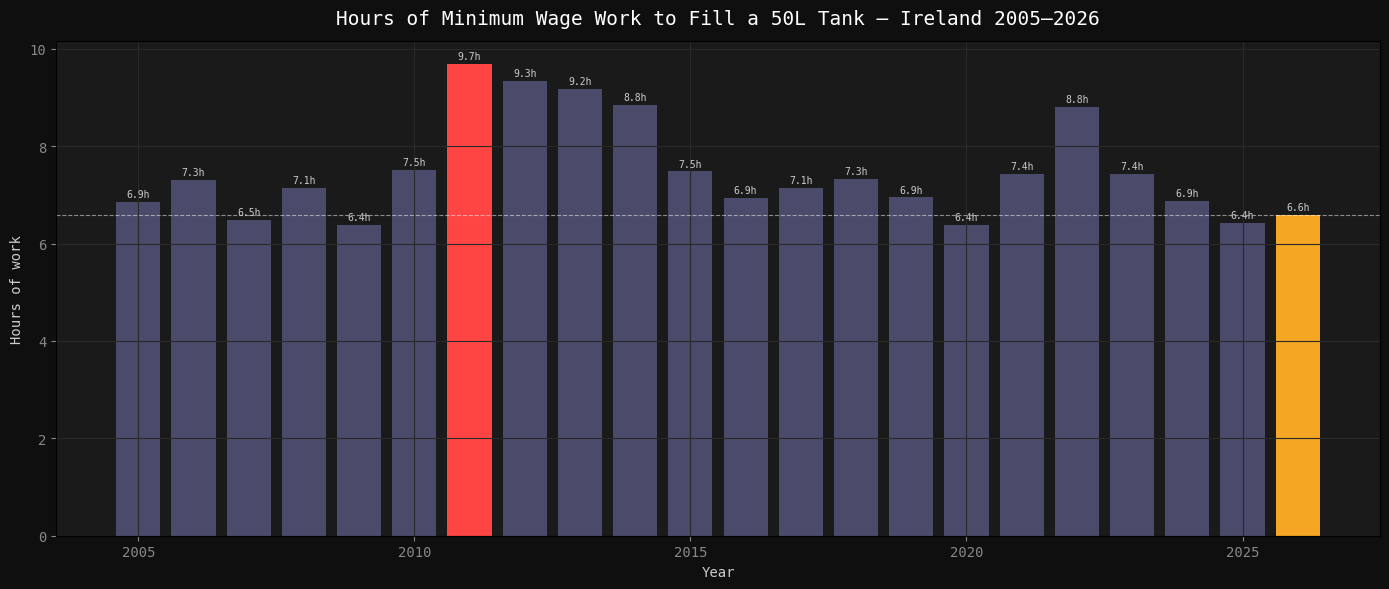

In [7]:
ie_annual = ie[ie['fuel_type'] == 'petrol_95'].copy()
ie_annual['year'] = ie_annual['date'].dt.year
ie_annual = ie_annual.groupby('year')['price_eur_per_litre'].mean()

min_wage = {
    2005: 7.65, 2006: 7.65, 2007: 8.65, 2008: 8.65, 2009: 8.65,
    2010: 8.65, 2011: 7.65, 2012: 8.65, 2013: 8.65, 2014: 8.65,
    2015: 9.15, 2016: 9.25, 2017: 9.55, 2018: 9.80, 2019: 10.10,
    2020: 10.10, 2021: 10.20, 2022: 10.50, 2023: 11.30, 2024: 12.70,
    2025: 13.50, 2026: 13.50,
}

hours = (ie_annual * 50) / pd.Series(min_wage)

fig, ax = plt.subplots(figsize=(14, 6))

colors = [CRISIS_RED if y == 2011 else DIESEL_ORANGE if y == 2026 else '#4a4a6a' for y in hours.index]
bars = ax.bar(hours.index, hours.values, color=colors, edgecolor='none')

for bar, val in zip(bars, hours.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            f'{val:.1f}h', ha='center', fontsize=7, color='#cccccc')

ax.axhline(hours.iloc[-1], color='#ffffff', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Hours of Minimum Wage Work to Fill a 50L Tank — Ireland 2005–2026', pad=12)
ax.set_ylabel('Hours of work')
ax.set_xlabel('Year')
fig.tight_layout()
plt.show()

In [8]:
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip")
world.loc[world['NAME'] == 'France', 'ISO_A2'] = 'FR'
world.loc[world['NAME'] == 'Ireland', 'ISO_A2'] = 'IE'
world.loc[world['NAME'] == 'Norway', 'ISO_A2'] = 'NO'

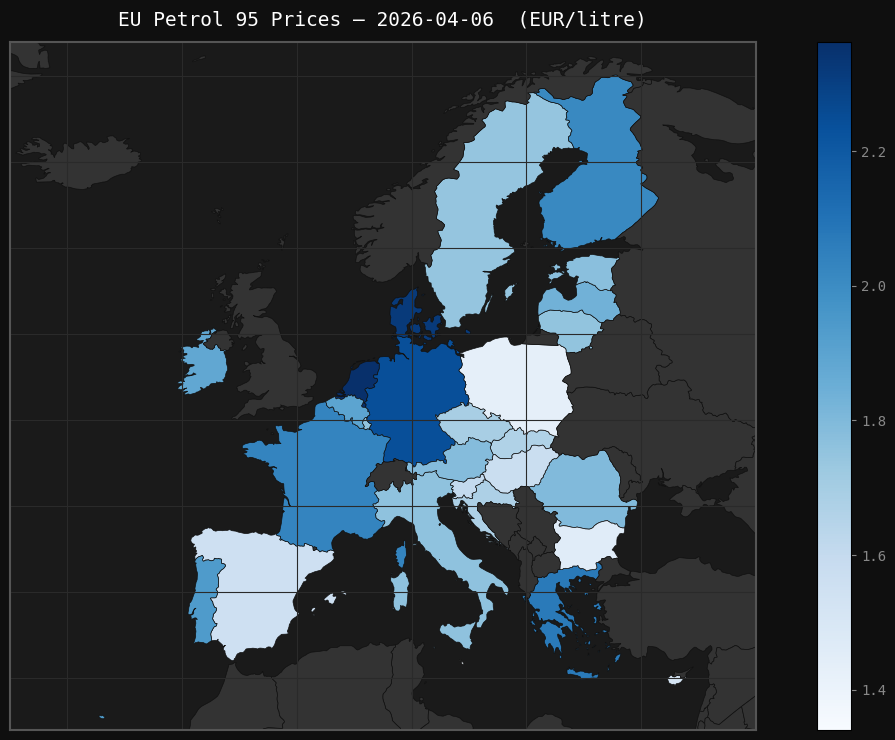

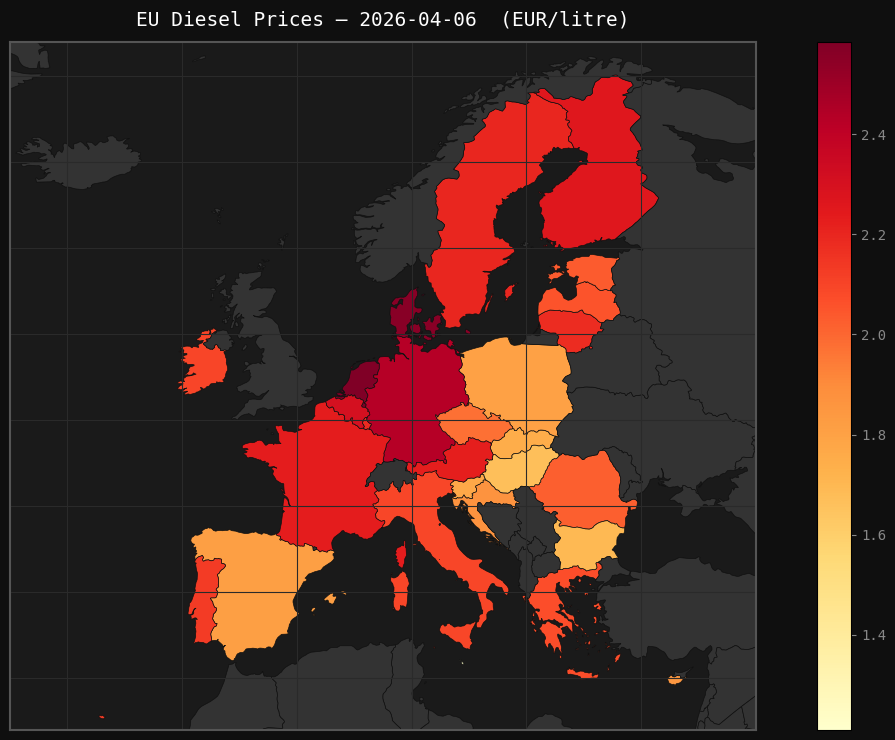

In [9]:
merged = world.merge(latest_petrol, left_on='ISO_A2', right_on='country', how='left')

fig, ax = plt.subplots(figsize=(12.5, 7.5))

# base layer first — non-EU countries show as dark grey
world.plot(ax=ax, color='#2a2a2a', edgecolor='#111111', linewidth=0.3)

# EU countries coloured by price on top
merged.plot(column='price_eur_per_litre', ax=ax, cmap='Blues', legend=True,
            edgecolor='#111111', linewidth=0.5,
            missing_kwds={'color': '#333333'})

ax.set_title(f'EU Petrol 95 Prices — {df_countries["date"].max().date()}  (EUR/litre)', pad=12)
ax.set_xlim(-25, 40)
ax.set_ylim(32, 72)
ax.set_aspect(1.5)
ax.axis('on')
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_edgecolor('#555555')
    spine.set_linewidth(1.5)
fig.tight_layout()
plt.show()

# diesel
merged = world.merge(latest_diesel, left_on='ISO_A2', right_on='country', how='left')

fig, ax = plt.subplots(figsize=(12.5, 7.5))

# base layer first — non-EU countries show as dark grey
world.plot(ax=ax, color='#2a2a2a', edgecolor='#111111', linewidth=0.3)

# EU countries coloured by price on top
merged.plot(column='price_eur_per_litre', ax=ax, cmap='YlOrRd', legend=True,
            edgecolor='#111111', linewidth=0.5,
            missing_kwds={'color': '#333333'})

ax.set_title(f'EU Diesel Prices — {df_countries["date"].max().date()}  (EUR/litre)', pad=12)
ax.set_xlim(-25, 40)
ax.set_ylim(32, 72)
ax.set_aspect(1.5)
ax.axis('on')
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_edgecolor('#555555')
    spine.set_linewidth(1.5)
fig.tight_layout()
plt.show()

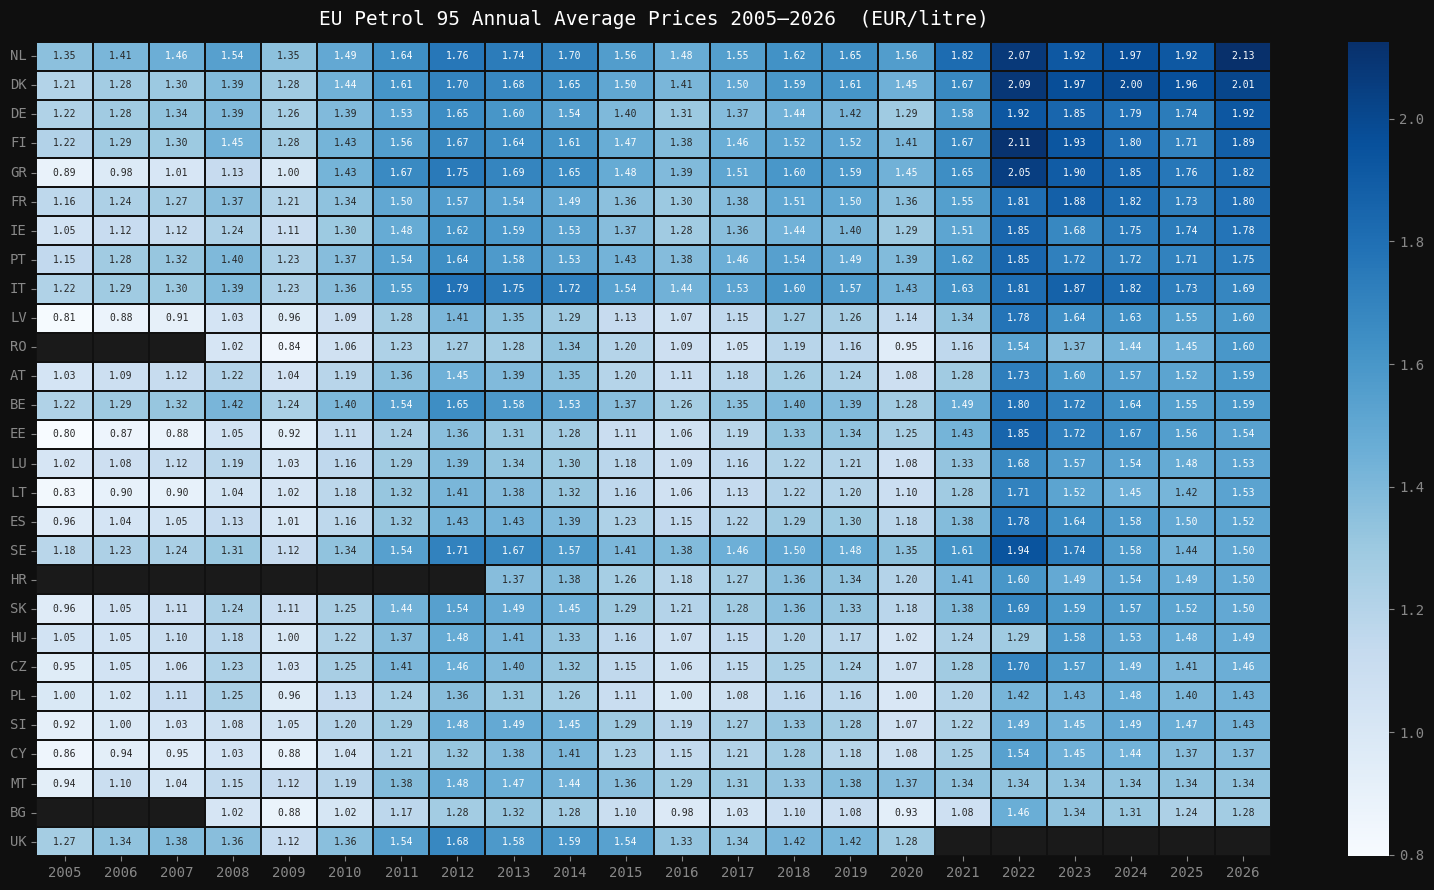

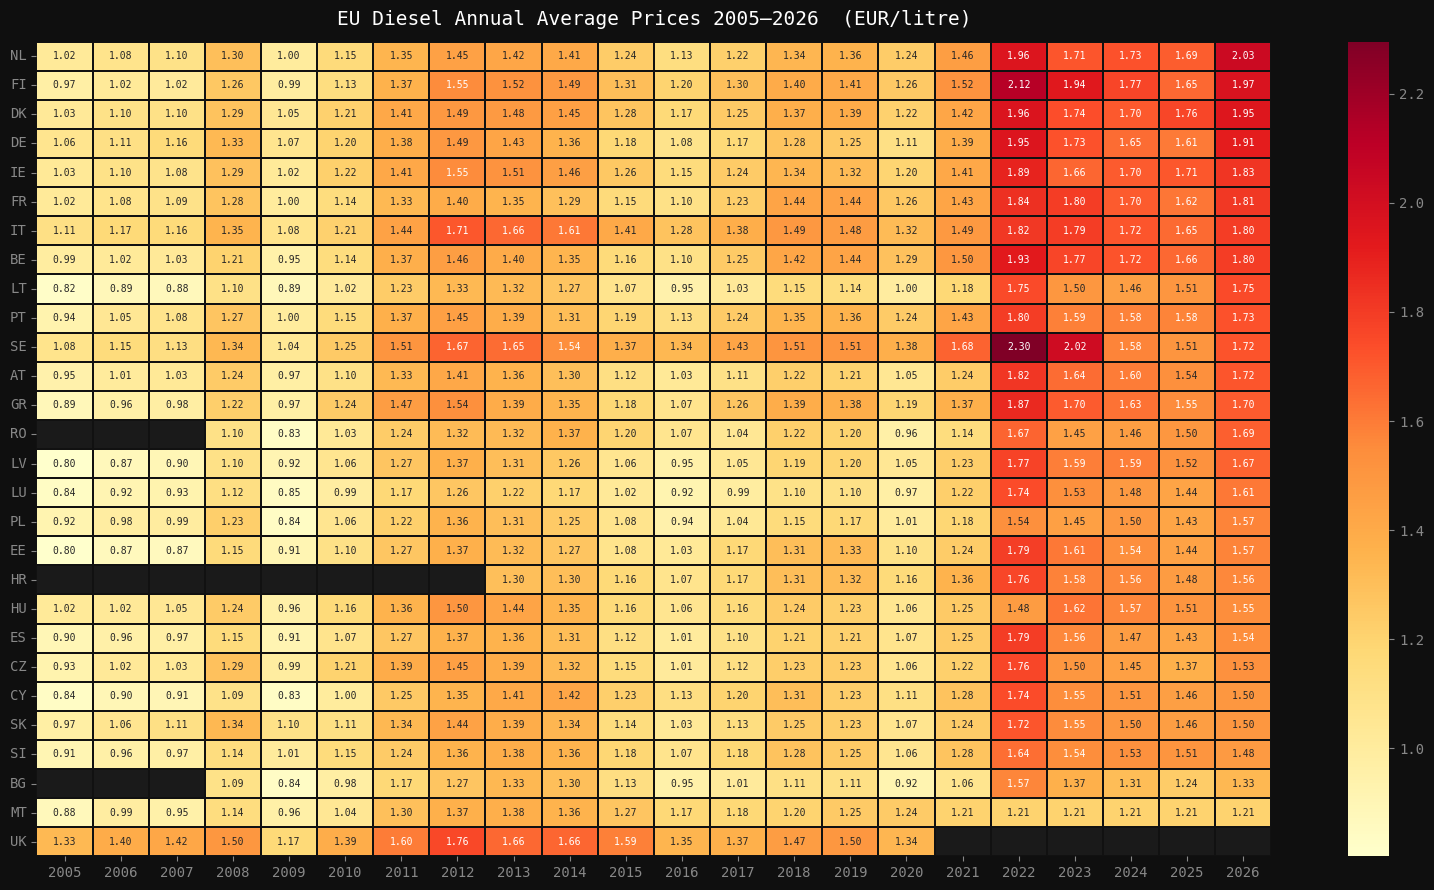

In [10]:
heat_data = df_countries[df_countries['fuel_type'] == 'petrol_95'].copy()
heat_data['year'] = heat_data['date'].dt.year
heat_pivot = heat_data.groupby(['country', 'year'])['price_eur_per_litre'].mean().unstack()
heat_pivot = heat_pivot.sort_values(heat_pivot.columns[-1], ascending=False)

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(heat_pivot, ax=ax, cmap='Blues', annot=True, fmt='.2f',
            annot_kws={'size': 7}, linewidths=0.3, linecolor='#111111')
ax.set_title('EU Petrol 95 Annual Average Prices 2005–2026  (EUR/litre)', pad=12)
plt.yticks(rotation=0)
ax.grid(False)
ax.set_xlabel('')
ax.set_ylabel('')
fig.tight_layout()
plt.show()

#diesel
heat_data = df_countries[df_countries['fuel_type'] == 'diesel'].copy()
heat_data['year'] = heat_data['date'].dt.year
heat_pivot = heat_data.groupby(['country', 'year'])['price_eur_per_litre'].mean().unstack()
heat_pivot = heat_pivot.sort_values(heat_pivot.columns[-1], ascending=False)

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(heat_pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
            annot_kws={'size': 7}, linewidths=0.3, linecolor='#111111')
ax.set_title('EU Diesel Annual Average Prices 2005–2026  (EUR/litre)', pad=12)
plt.yticks(rotation=0)
ax.grid(False)
ax.set_xlabel('')
ax.set_ylabel('')
fig.tight_layout()
plt.show()

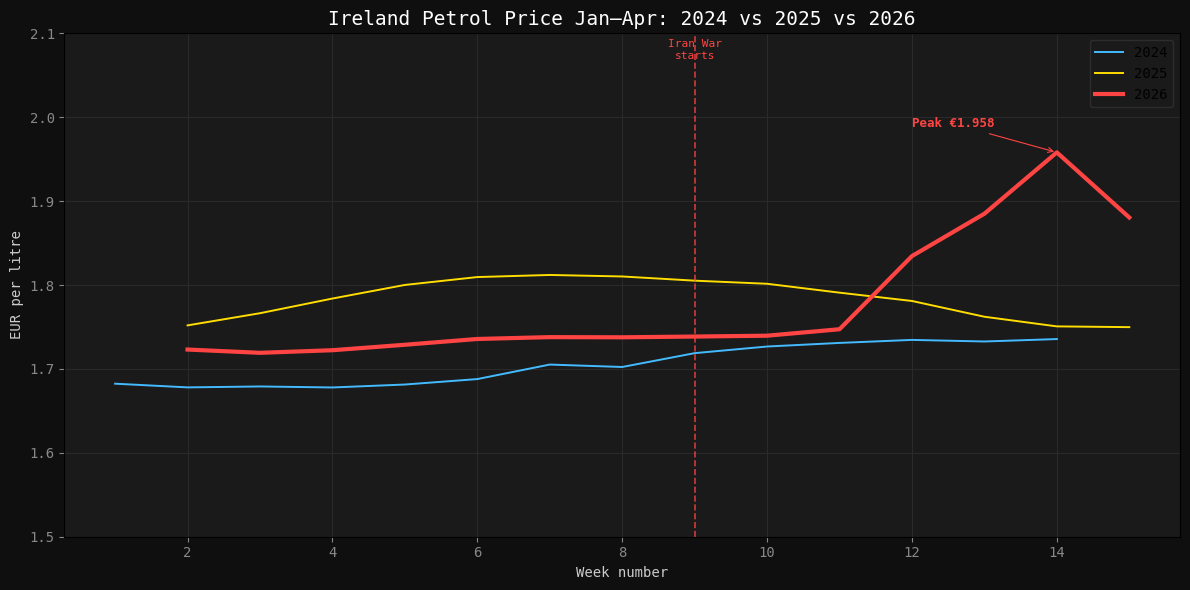

In [11]:
latest_2026 = ie_petrol[
    (ie_petrol.index.year == 2026) &
    (ie_petrol.index.month <= 4)
]

fig, ax = plt.subplots(figsize=(12, 6))
for year, color in zip([2024, 2025, 2026], crisis_colors[1:]):
    series = ie_petrol[
        (ie_petrol.index.year == year) &
        (ie_petrol.index.month <= 4)
    ]
    series = series.iloc[:len(latest_2026)]
    weeks = series.index.isocalendar().week.values
    lw = 3 if year == 2026 else 1.4
    ax.plot(weeks, series.values, label=year, color=color, linewidth=lw)

ax.axvline(9, color=CRISIS_RED, linewidth=1.2, linestyle='--', alpha=0.8)
ax.text(9, 2.07, 'Iran War\nstarts', color=CRISIS_RED, fontsize=8, ha='center')

peak_week = latest_2026.index.isocalendar().week.values[latest_2026.values.argmax()]
peak_val = latest_2026.max()
ax.annotate(f'Peak €{peak_val:.3f}',
            xy=(peak_week, peak_val),
            xytext=(peak_week - 2, peak_val + 0.03),
            color=CRISIS_RED, fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=CRISIS_RED, lw=0.8))

ax.set_title('Ireland Petrol Price Jan–Apr: 2024 vs 2025 vs 2026')
ax.set_ylabel('EUR per litre')
ax.set_xlabel('Week number')
ax.set_ylim(1.50, 2.10)
ax.legend()
fig.tight_layout()
plt.show()

In [12]:
print('=== KEY FINDINGS ===')
print(f"Ukraine war: diesel rising at \033[1m{diesel_slope[2][1]:.2f}\033[0m index points/week")
print(f"Iran war:    diesel rising at \033[1m{diesel_slope[3][1]:.2f}\033[0m index points/week")
print(f"→ Iran war is driving prices \033[1m{diesel_slope[3][1] / diesel_slope[2][1]:.1f}x\033[0m faster than Ukraine war")

print(f"\nIreland petrol Jan 2026:  €\033[1m{ie_petrol[ie_petrol.index.year == 2026].iloc[0]:.3f}\033[0m/litre")
print(f"Ireland petrol peak 2026: €\033[1m{ie_petrol[ie_petrol.index.year == 2026].max():.3f}\033[0m/litre")
print(f"→ Up €\033[1m{ie_petrol[ie_petrol.index.year == 2026].max() - ie_petrol[ie_petrol.index.year == 2026].iloc[0]:.3f}\033[0m (+\033[1m{((ie_petrol[ie_petrol.index.year == 2026].max() / ie_petrol[ie_petrol.index.year == 2026].iloc[0]) - 1) * 100:.1f}%\033[0m) in 8 weeks")

print(f"\nDiesel all time high: €\033[1m{ie_diesel.max():.3f}\033[0m on \033[1m{ie_diesel.idxmax().date()}\033[0m")
print(f"Petrol 21yr increase: +\033[1m{((ie_petrol.iloc[-1] / ie_petrol.iloc[0]) - 1) * 100:.1f}%\033[0m since Jan 2005")
print(f"Diesel 21yr increase: +\033[1m{((ie_diesel.iloc[-1] / ie_diesel.iloc[0]) - 1) * 100:.1f}%\033[0m since Jan 2005")
print(f"Worst year for min wage workers: 2011 — \033[1m{hours[2011]:.1f} hours\033[0m to fill a 50L tank")

=== KEY FINDINGS ===
Ukraine war: diesel rising at 0.93 index points/week
Iran war:    diesel rising at 5.33 index points/week
→ Iran war is driving prices 5.7x faster than Ukraine war

Ireland petrol Jan 2026:  €1.723/litre
Ireland petrol peak 2026: €1.958/litre
→ Up €0.235 (+13.6%) in 8 weeks

Diesel all time high: €2.178 on 2026-03-30
Petrol 21yr increase: +86.4% since Jan 2005
Diesel 21yr increase: +115.3% since Jan 2005
Worst year for min wage workers: 2011 — 9.7 hours to fill a 50L tank
